**Further Exploration of BT models**

In [2]:
!pip install bertopic sentence-transformers umap-learn hdbscan scikit-learn pandas matplotlib
from bertopic import BERTopic
import pandas as pd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
from google.colab import drive

import os

import numpy as np



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.6/150.6 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 119.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 115.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta

In [3]:
print("GPU Available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"

GPU Available: True


In [5]:
drive.mount('/content/drive')

print(os.path.exists("/content/drive/MyDrive/prolife_berttopic"))
print(os.path.exists("/content/drive/MyDrive/prochoice_berttopicv1"))

Mounted at /content/drive
True
True


In [6]:
pc = BERTopic.load("/content/drive/MyDrive/prochoice_berttopicv1")
pl = BERTopic.load("/content/drive/MyDrive/prolife_berttopic")


In [7]:
pcti = pc.get_topic_info()

pctiCount = pcti[1:].reset_index(drop = True)

In [8]:
pctiCount['Count'].sum()

np.int64(8317)

In [9]:
1227 / 8317

0.1475291571480101

In [18]:
labels = {
   -1: "Undefined",
   0: "Bodily Autonomy and Reproductive Rights",
   1: "Sharing Resources and Information",
   2: "Politics of Control (Government Control and Policy)",
   3: "Elections, Voting, and Political Influence",
   4: "Criticism of Republican Policies",
   5: "General Pro-Choice Discussions",
   6: "State-Level Abortion Laws and Restrictions",
   7: "Religion’s Role in Abortion Debates",
   8: "Early Pregnancy Detection and Abortion Bans",
   9: "Forced Birth and Reproductive Coercion",
   10: "Health Risks and Medical Considerations",
   11: "Women",
   12: "Rape Exceptions in Abortion Laws",
   13: "Supreme Court Decisions and Legal Debates",
   14: "Gender Dynamics and Inequalities",
   15: "Criticism of Pro-Life: 'Pro-Birth, Not Pro-Life'",
   16: "Handmaid’s Tale Comparisons",
   17: "Pro-Life and Anti-Choice Perspectives",
   18: "Roe v. Wade and Its Impact",
   19: "Cells vs Fetus vs Human Life (Terminology in Discussions)",
   20: "Birth Control and Contraceptive Access",
   21: "Trans Rights",
   21: "Emotional Burden and Decision-Making in Abortion",
   22: "Abortion Ban Timelines and Viability Limits",
   23: "International Abortion",
   24: "Discussions About Other Countries",
   25: "Late-Term Abortion Discussions",
   26: "Hypocrisy in Abortion and Death Penalty Debates",
   27: "Medical Ethics and Privacy Concerns",
   28: "Vasectomies, Gender, and Reproductive Responsibilities",
   29: "Religious Influence on Abortion Laws",
   30: "Critiques Comparing Abortion Restrictions to Slavery",
   31: "Murder and Killing Rhetoric in Abortion Debate",
   32: "Pro-Life Discussions and Arguments",
   33: "Gun Rights (including Abortion Rights Comparisons)"
}


pcti['label'] = pcti['Topic'].map(labels)


In [17]:
pcti

,Topic,Count,Name,Representation,Representative_Docs,label
0,-1,7929,-1_abortion_women_life_pro,"[abortion, women, life, pro, people, woman, fe...","[pro-choicers have been hashing these ""ethical...",Undefined
1,0,1227,0_autonomy_body_bodily_bodily autonomy,"[autonomy, body, bodily, bodily autonomy, righ...",[that is not what bodily autonomy means. the ...,Bodily Autonomy and Reproductive Rights
2,1,672,1_thank_oh_link_lol,"[thank, oh, link, lol, good, read, know, artic...","[link, oh no! anyway., *""oh no!! what will we...",Sharing Resources and Information
3,2,617,2_women_want_conservatives_control,"[women, want, conservatives, control, abortion...","[women want to control other women., to own wo...",Politics of Control (Government Control and Po...
4,3,586,3_vote_democrat_party_democrats,"[vote, democrat, party, democrats, biden, trum...",[this is why it's important to push back again...,"Elections, Voting, and Political Influence"
5,4,486,4_republicans_women_abortion_gop,"[republicans, women, abortion, gop, want, repu...",[republicans have tried to pass hundreds of la...,Criticism of Republican Policies
6,5,461,5_pro_pro choice_choice_abortion,"[pro, pro choice, choice, abortion, pro aborti...","[and that is being pro choice., again, pro cho...",General Pro-Choice Discussions
7,6,417,6_texas_state_abortion_states,"[texas, state, abortion, states, women, ban, a...","[first, the types of people who support the le...",State-Level Abortion Laws and Restrictions
8,7,367,7_religious_abortion_religion_people,"[religious, abortion, religion, people, life, ...",[that is what the traditional anti-abortion mo...,Religion’s Role in Abortion Debates
9,8,305,8_weeks_pregnancy_pregnant_abortion,"[weeks, pregnancy, pregnant, abortion, period,...","[you, like many gop politicians, don't underst...",Early Pregnancy Detection and Abortion Bans


In [ ]:
plti = pl.get_topic_info()

labels = {
   -1: 'NaN',
   0: 'Abortion as Murder and Killing',
   1: 'Right to Life',
   2: 'Politics and Voting',
   3: 'Defining Human Life (Life Begins at Conception)',
   4: 'Sharing Links',
   5: 'No Exceptions for Abortion (Rape, Incest, etc.)',
   6: 'Babies',
   7: 'Religious Opposition to Abortion',
   8: 'Mixed, speaking about women, killing, and babies',
   9: 'Abortion as Genocide and Extreme Comparisons',
   10: 'Bodily Autonomy in the Pro-Life Debate',
   11: 'Personal Responsibility',
   12: 'Healthcare',
   13: 'Adoption as an Alternative to Abortion',
   14: 'Planned Parenthood',
   15: 'Unrelated Topics (Economy, General Issues)',
   16: 'Guns',
   17: 'Anti-Democrat Views and Protests',
}

plti = plti[1:]
plti.head(10)

# plti['label'] = plti['Topic'].map(labels)

# plti

# plti = plti[['Topic', 'Count', 'label', 'Name', 'Representation']]

# plti

,Topic,Count,Name,Representation,Representative_Docs
1,0,3751,0_murder_killing_life_abortion,"[murder, killing, life, abortion, kill, babies...","[it's still murder, so no.., it is murder., no..."
2,1,468,1_right_abortion_life_rights,"[right, abortion, life, rights, right life, un...","[the right to life, what about the right to li..."
3,2,399,2_vote_democrats_court_trump,"[vote, democrats, court, trump, like, people, ...",['virtually all validated voters with consiste...
4,3,343,3_human_life_conception_begins,"[human, life, conception, begins, life begins,...","[life begins at conception., life begins at co..."
5,4,313,4_link_lol_said_like,"[link, lol, said, like, just, la, read, oh, la...","[link, link, link]"
6,5,284,5_rape_child_baby_life,"[rape, child, baby, life, incest, innocent, ra...","[if you want to make a triage argument, i doub..."
7,6,275,6_baby_baby baby_babies_babies baby,"[baby, baby baby, babies, babies baby, baby ba...","[but less than a baby., not for the baby., it'..."
8,7,200,7_god_religion_church_babies,"[god, religion, church, babies, satan, killing...",[that's the idea; demonize your enemies. i do...
9,8,175,8_shes_baby_killed_killing,"[shes, baby, killed, killing, babies, did, peo...","[i posted this in the wrong spot but yes, shes..."
10,9,128,9_unborn_logic lived_agree use_control unborn,"[unborn, logic lived, agree use, control unbor...",[it's undeniably murder. unborn babies have th...


In [ ]:
plTotal = plti['Count'].sum()
print(plTotal)
468 / plTotal

6784


np.float64(0.06898584905660378)

In [ ]:
plti = plti[1:]

pcTotal = pcti['Count'].sum()
plTotal = plti['Count'].sum()

pcPro = (pcti['Count'] / pcTotal).to_list()
plPro = (plti['Count'] / plTotal).to_list()

pcTopics = pcti['Topic'].to_list()
plTopics = plti['Topic'].to_list()

df  = pd.DataFrame({
    'Topic': pcTopics,
    'Percent': pcPro
})

dfPL  = pd.DataFrame({
    'Topic': plTopics,
    'Percent': plPro
})
dfPL





,Topic,Percent
0,0,0.552919
1,1,0.068986
2,2,0.058815
3,3,0.050560
4,4,0.046138
5,5,0.041863
6,6,0.040537
7,7,0.029481
8,8,0.025796
9,9,0.018868


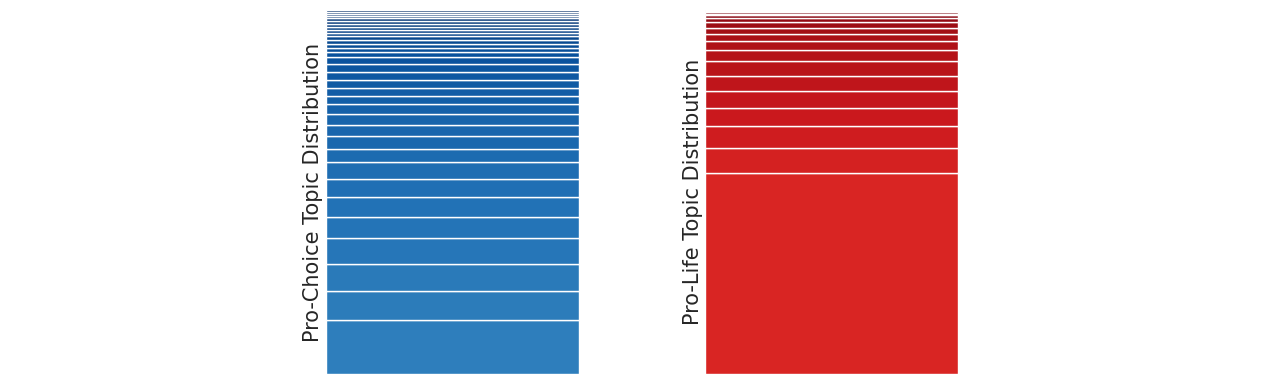

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4))

colors_blue = plt.cm.Blues(np.linspace(0.7, 1.0, len(df)))
colors_red = plt.cm.Reds(np.linspace(0.7, 1.0, len(dfPL)))


bottom = 0
for i in range(len(df)):
    ax.bar(-0.3, df['Percent'].iloc[i], bottom=bottom, color=colors_blue[i], width=0.4)
    bottom += df['Percent'].iloc[i]

bottom = 0
for i in range(len(dfPL)):
    ax.bar(0.3, dfPL['Percent'].iloc[i], bottom=bottom, color=colors_red[i], width=0.4)
    bottom += dfPL['Percent'].iloc[i]

ax.set_xlim(-1, 1)
ax.set_ylim(0, 1)
ax.axis('off')

ax.text(-0.52, 0.5, 'Pro-Choice Topic Distribution', ha='center', va='center', fontsize=15, rotation=90)
ax.text(0.080, 0.5, 'Pro-Life Topic Distribution', ha='center', va='center', fontsize=15, rotation=90)

plt.savefig('commentStacked.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()



In [ ]:
plt.savefig('commentStacked.png', dpi=300, bbox_inches='tight')


<Figure size 640x480 with 0 Axes>

In [ ]:
from scipy.stats import fisher_exact

table = [[54, 17],
         [57, 2]]

oddsratio, p = fisher_exact(table)
print(f"Odds ratio = {oddsratio}, p-value = {p}")


In [ ]:
baby = pl.get_topics()[6]

women = pc.get_topics()[11]

women

[('woman', np.float64(0.1456852975205513)),
 ('women', np.float64(0.09855635899191328)),
 ('woman women', np.float64(0.09575101049817578)),
 ('woman woman', np.float64(0.08429121188145092)),
 ('women women', np.float64(0.08295681922602952)),
 ('women woman', np.float64(0.0744313967289499)),
 ('nasty woman', np.float64(0.03647862016548673)),
 ('shes', np.float64(0.03645563202094115)),
 ('brave', np.float64(0.03230326754379518)),
 ('nasty', np.float64(0.03204524242193325))]

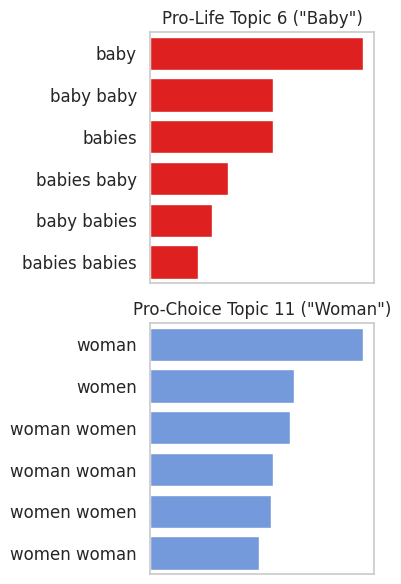

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_baby = pd.DataFrame(baby, columns=['Word', 'Weight'])[:6]
df_women = pd.DataFrame(women, columns=['Word', 'Weight'])[:6]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 6))  # 2 rows, 1 column

sns.barplot(x='Weight', y='Word', data=df_baby, ax=ax1, color='red')
ax1.set_title('Pro-Life Topic 6 ("Baby")', fontsize=12)
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.xaxis.set_visible(False)
ax1.yaxis.set_tick_params(labelsize=12)

sns.barplot(x='Weight', y='Word', data=df_women, ax=ax2, color='cornflowerblue')
ax2.set_title('Pro-Choice Topic 11 ("Woman")', fontsize=12)
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.xaxis.set_visible(False)
ax2.yaxis.set_tick_params(labelsize=12)

plt.tight_layout()
plt.savefig('babyWoman.png', dpi=300, bbox_inches='tight')
plt.show()

